# Nhiệm vụ 7: Đánh giá Chất lượng Cụm (Cluster Quality Evaluation) — K-Means Baseline

**Mục tiêu nhiệm vụ:** Đánh giá chất lượng của mô hình K-Means Baseline (K=2) trên 15 snapshots development (11/2023 - 01/2025) bằng 5 chỉ số chất lượng nội bộ độc lập:
- **Phần 7.1:** Silhouette Score
- **Phần 7.2:** Davies-Bouldin Index
- **Phần 7.3:** Calinski-Harabasz Index
- **Phần 7.4:** Inertia
- **Phần 7.5:** Cluster Balance

**Quy trình thực hiện:**
1. Đọc artifact chẩn đoán từ `M2/artifacts/m2-evaluation-kmeans/quality_metrics_comparison.csv`.
2. Trích xuất kết quả tại cấu hình Global K=2 đã khóa ở Nhiệm vụ 3.
3. Phân tích chi tiết 5 chỉ số chất lượng từ 7.1 đến 7.5 và trực quan hóa chuỗi thời gian.
4. Xuất bảng tổng hợp thống kê không trọng số và chi tiết 15 snapshots.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

eval_dir = '../artifacts/m2-evaluation-kmeans' if os.path.exists('../artifacts/m2-evaluation-kmeans') else 'M2/artifacts/m2-evaluation-kmeans'
df_quality_all = pd.read_csv(os.path.join(eval_dir, 'quality_metrics_comparison.csv'))
df_quality = df_quality_all[df_quality_all['k'] == 2].copy()
df_summary = pd.read_csv(os.path.join(eval_dir, 'quality_summary.csv'))

print("=== BẢNG TỔNG HỢP CHỈ SỐ CHẤT LƯỢNG (15 SNAPSHOTS) ===")
summary_display = df_summary[['metric', 'n_total', 'mean', 'median', 'minimum', 'maximum']].copy()
summary_display.columns = ['Metric', 'Số quan sát', 'Mean', 'Median', 'Min', 'Max']
print(summary_display.round(6).to_string(index=False))


=== BẢNG TỔNG HỢP CHỈ SỐ CHẤT LƯỢNG (15 SNAPSHOTS) ===
           Metric  Số quan sát         Mean      Median         Min           Max
       silhouette           15     0.791489    0.755722    0.636868      0.949859
   davies_bouldin           15     0.514798    0.521899    0.356337      0.747218
calinski_harabasz           15   687.889134  316.391783  160.006764   2046.647682
          inertia           15 53746.201833 2158.608251 1304.124507 329664.086867
  cluster_balance           15     0.056407    0.067669    0.010363      0.094972


### Phần 7.1 — Silhouette Score

**Mục đích:** Đo mức tương đồng của một điểm với cụm của nó so với cụm khác. Cao hơn là tốt hơn (ngưỡng chấp nhận > 0.5).


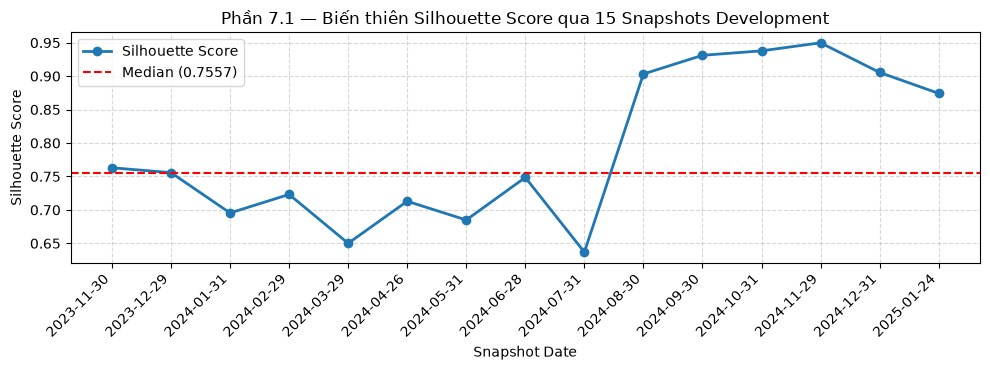

In [2]:
plt.figure(figsize=(10, 3.8))
plt.plot(df_quality['snapshot_date'], df_quality['silhouette'], marker='o', color='#1f77b4', linewidth=2, label='Silhouette Score')
plt.axhline(df_quality['silhouette'].median(), color='red', linestyle='--', label=f"Median ({df_quality['silhouette'].median():.4f})")
plt.title('Phần 7.1 — Biến thiên Silhouette Score qua 15 Snapshots Development')
plt.xlabel('Snapshot Date')
plt.ylabel('Silhouette Score')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


### Phần 7.2 — Davies-Bouldin

**Mục đích:** Đo tỷ số giữa độ phân tán trong cụm và khoảng cách giữa các tâm cụm. Thấp hơn là tốt hơn (ngưỡng tốt < 1.0).


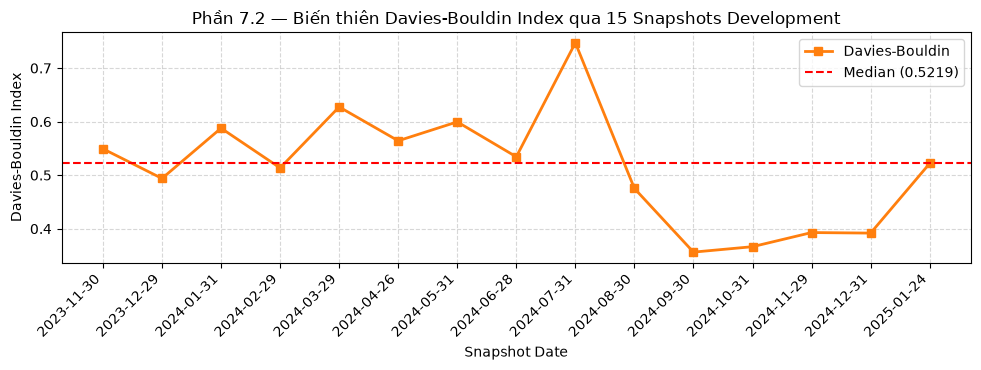

In [3]:
plt.figure(figsize=(10, 3.8))
plt.plot(df_quality['snapshot_date'], df_quality['davies_bouldin'], marker='s', color='#ff7f0e', linewidth=2, label='Davies-Bouldin')
plt.axhline(df_quality['davies_bouldin'].median(), color='red', linestyle='--', label=f"Median ({df_quality['davies_bouldin'].median():.4f})")
plt.title('Phần 7.2 — Biến thiên Davies-Bouldin Index qua 15 Snapshots Development')
plt.xlabel('Snapshot Date')
plt.ylabel('Davies-Bouldin Index')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


### Phần 7.3 — Calinski-Harabasz

**Mục đích:** Đo tỷ số giữa phương sai giữa các cụm và phương sai trong nội cụm. Cao hơn là phân cụm càng chặt chẽ.


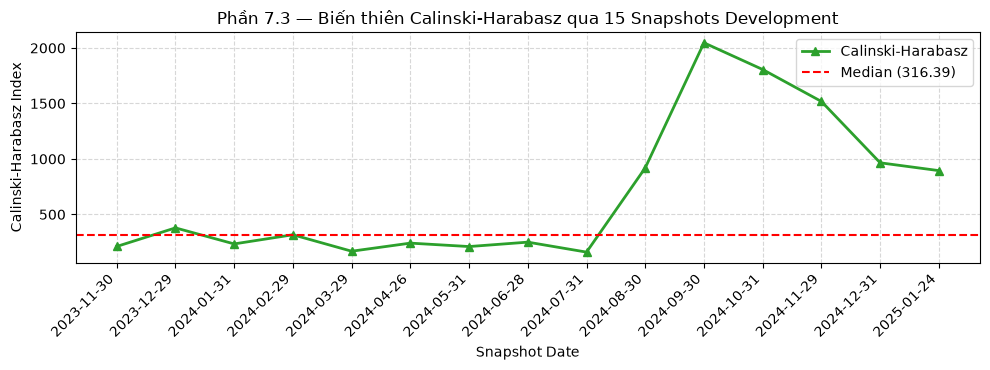

In [4]:
plt.figure(figsize=(10, 3.8))
plt.plot(df_quality['snapshot_date'], df_quality['calinski_harabasz'], marker='^', color='#2ca02c', linewidth=2, label='Calinski-Harabasz')
plt.axhline(df_quality['calinski_harabasz'].median(), color='red', linestyle='--', label=f"Median ({df_quality['calinski_harabasz'].median():.2f})")
plt.title('Phần 7.3 — Biến thiên Calinski-Harabasz qua 15 Snapshots Development')
plt.xlabel('Snapshot Date')
plt.ylabel('Calinski-Harabasz Index')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


### Phần 7.4 — Inertia

**Mục đích:** Tổng khoảng cách bình phương nội cụm trong không gian Robust Scale (hàm mục tiêu của K-Means).


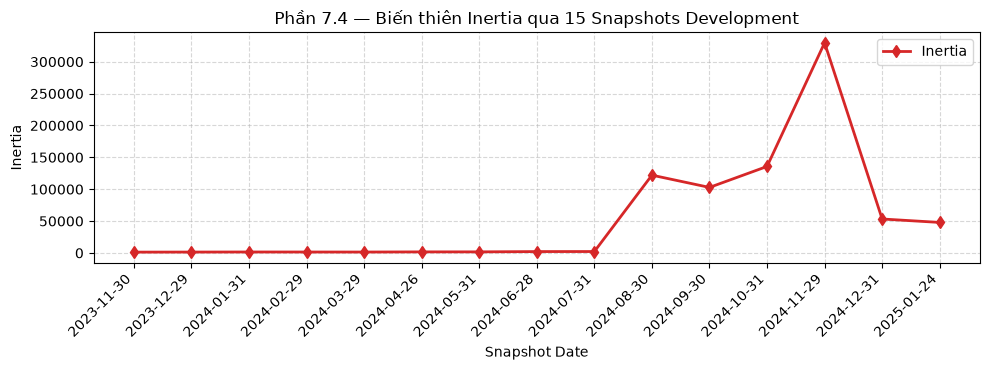

In [5]:
plt.figure(figsize=(10, 3.8))
plt.plot(df_quality['snapshot_date'], df_quality['inertia'], marker='d', color='#d62728', linewidth=2, label='Inertia')
plt.title('Phần 7.4 — Biến thiên Inertia qua 15 Snapshots Development')
plt.xlabel('Snapshot Date')
plt.ylabel('Inertia')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


### Phần 7.5 — Cluster balance

**Mục đích:** Đo mức độ đồng đều kích thước cụm qua tỷ số giữa cụm nhỏ nhất và cụm lớn nhất (min_size / max_size).


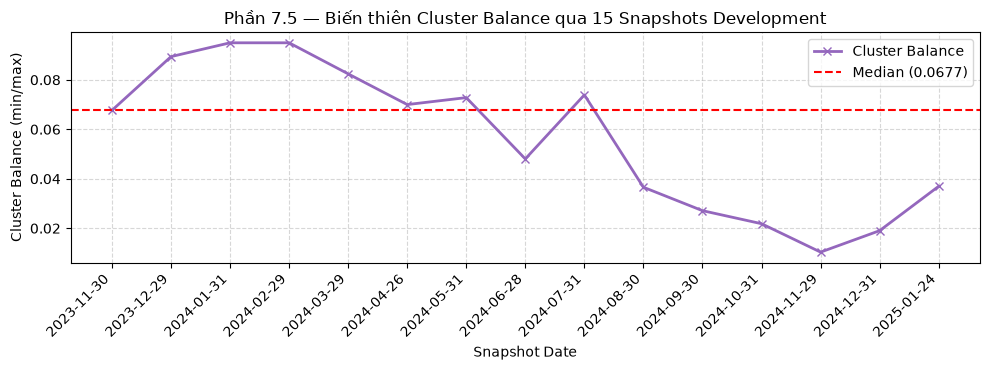

In [6]:
plt.figure(figsize=(10, 3.8))
plt.plot(df_quality['snapshot_date'], df_quality['cluster_balance'], marker='x', color='#9467bd', linewidth=2, label='Cluster Balance')
plt.axhline(df_quality['cluster_balance'].median(), color='red', linestyle='--', label=f"Median ({df_quality['cluster_balance'].median():.4f})")
plt.title('Phần 7.5 — Biến thiên Cluster Balance qua 15 Snapshots Development')
plt.xlabel('Snapshot Date')
plt.ylabel('Cluster Balance (min/max)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


In [7]:
cols_show = ['snapshot_date', 'n_eligible', 'smallest_cluster', 'largest_cluster', 'silhouette', 'davies_bouldin', 'calinski_harabasz', 'inertia', 'cluster_balance']
df_table_out = df_quality[cols_show].copy()
df_table_out.columns = ['Snapshot', 'Số mã', 'Cụm min', 'Cụm max', 'Silhouette', 'DB', 'CH', 'Inertia', 'Balance']
print("=== CHI TIẾT 15 SNAPSHOTS K-MEANS BASELINE (K=2) ===")
print(df_table_out.round(6).to_string(index=False))


=== CHI TIẾT 15 SNAPSHOTS K-MEANS BASELINE (K=2) ===
  Snapshot  Số mã  Cụm min  Cụm max  Silhouette       DB          CH       Inertia  Balance
2023-11-30    142        9      133    0.762987 0.549272  210.950916   1304.124507 0.067669
2023-12-29    195       16      179    0.755722 0.493906  378.398170   1396.643410 0.089385
2024-01-31    196       17      179    0.695411 0.587799  233.930208   1520.946055 0.094972
2024-02-29    196       17      179    0.723123 0.513532  316.391783   1480.098520 0.094972
2024-03-29    197       15      182    0.650054 0.627474  168.131090   1425.637654 0.082418
2024-04-26    214       14      200    0.712929 0.564229  241.057790   1668.300555 0.070000
2024-05-31    221       15      206    0.684901 0.599560  210.151850   1706.906717 0.072816
2024-06-28    240       11      229    0.748492 0.534333  249.860699   2158.608251 0.048035
2024-07-31    247       17      230    0.636868 0.747218  160.006764   2215.034630 0.073913
2024-08-30    595       21 